0) Aplicar descenso del gradiente óptimo a la función :

$$f(x,y)=x^2+2y^2−2xy−2y$$ 

In [1]:
from sympy import *
import matplotlib.pyplot as plt
import numpy as np

In [2]:
x, y, t = symbols('x y t')

In [3]:
Derivar

Sustituir valores en la derivada (se obtiene punto)

x' + t*grad(f(x')) = punto de antes * t

Sustituyo punto en ecuacion original, derivo y despejo y optengo optimo para esa iteracion





def learnin_rate_decay(punto, ecuacion):

    

In [4]:
def grad(ecuacion, alfa0, inicial, maxit, tol):

    alfa, punto_x, punto_y  = [[] for val in range(3)]

    decuacion_x , decuacion_y = diff(ecuacion,x), diff(ecuacion,y)

    critico_vector = list(solve((decuacion_x , decuacion_y), x, y).values())


    i = 0
    while ( abs(inicial[0] - critico_vector[0]) > tol or abs(inicial[1] - critico_vector[1]) > tol ) and i < maxit:

        alfa.append(learnin_rate_decay(1, alfa0, i))

        inicial[0] = inicial[0] - learnin_rate_decay(1, alfa0, i) * decuacion_x.subs([(x,inicial[0]),(y,inicial[1])]) 
        inicial[1] = inicial[1] - learnin_rate_decay(1, alfa0, i) * decuacion_y.subs([(x,inicial[0]),(y,inicial[1])])

        punto_x.append(inicial[0])
        punto_y.append(inicial[1])
        i += 1

    return inicial, alfa, [punto_x, punto_y]

In [5]:
descenso_graciente = grad(x**2 +2*y**2 -2*x*y -2*y, 0.5, [20,20], 100, 0.1)

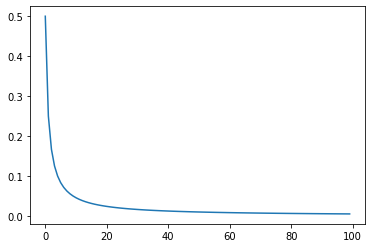

In [6]:
plt.plot(descenso_graciente[1])

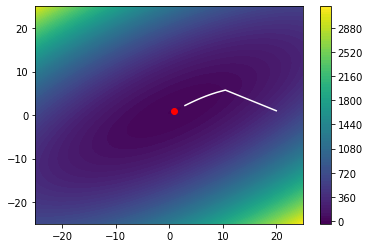

In [7]:
#Prepara los datos para dibujar mapa de niveles de Z
resolucion = 100 
rango=25
 
X=np.linspace(-rango,rango,resolucion) 
Y=np.linspace(-rango,rango,resolucion)
Z=np.zeros((resolucion,resolucion))
f  = lambda X: X[0]**2 + 2*X[1]**2 - 2*X[0]*X[1] - 2*X[1]
for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[iy,ix] = f([x,y])

#Pinta el mapa de niveles de Z
plt.contourf(X,Y,Z,resolucion)
plt.colorbar() ## barra vertical al lado del dibujo en los ejes de coordenadas
plt.plot(1,1,"o",c="red")

plt.plot(descenso_graciente[2][0],descenso_graciente[2][1],c="white")

plt.show()

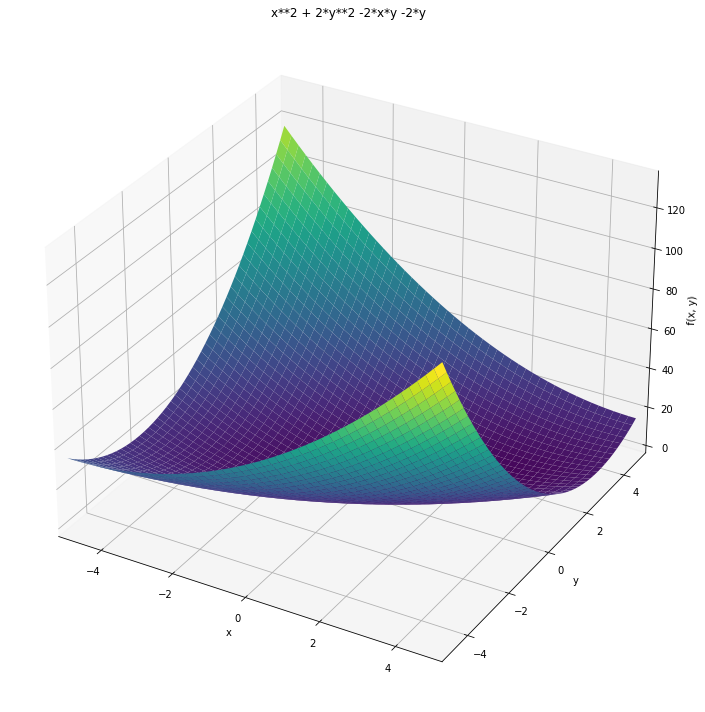

Punto Inicial:  [1.8959461530807609, -0.39847291759976233]


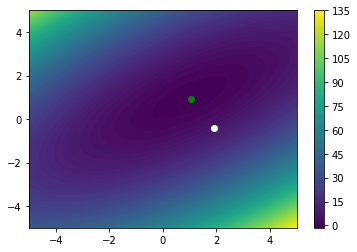

Solucion: [1.0573982660574102, 0.9414044588046047] -0.9831119992310176
La solucion deberia tender al punto (1,1)


In [22]:
## dibujamos la función
##############################


plot3d(x**2 +2*y**2 -2*x*y -2*y ,
       (x,-5,5),(y,-5,5),
       title='x**2 + 2*y**2 -2*x*y -2*y',
       size=(10,10))

#Definimos la funcion y su gradiente

f  = lambda X: X[0]**2 + 2*X[1]**2 - 2*X[0]*X[1] - 2*X[1]
df = lambda X: [2*X[0]-2*X[1],4*X[1]-2*X[0]-2]
#df([1,2])

#Prepara los datos para dibujar mapa de niveles de Z
resolucion = 100 
rango=5
 
X=np.linspace(-rango,rango,resolucion) 
Y=np.linspace(-rango,rango,resolucion)
Z=np.zeros((resolucion,resolucion))
for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[iy,ix] = f([x,y])

#Pinta el mapa de niveles de Z
plt.contourf(X,Y,Z,resolucion)
plt.colorbar() ## barra vertical al lado del dibujo en los ejes de coordenadas

#Generamos un punto aleatorio inicial y pintamos de blanco
P_ini=[random.uniform(-2,2  ),random.uniform(-2,2 ) ]
print("Punto Inicial: ",P_ini)
plt.plot(P_ini[0],P_ini[1],"o",c="white") ## "o" indica que es un punto que se dibuja

#Tasa de aprendizaje. Fija. Sería más efectivo reducirlo a medida que nos acercamos.
TA=0.1
## Numero de iteraciones
num_iter = 100
## Punto inicial 
P = P_ini

## ALGORITMO DEL DESCENSO DEL GRADIENTE

for i in range(num_iter):
  grad = df(P)
  P[0], P[1] = P[0] -learnin_rate_decay(1, TA, i)*grad[0], P[1] - learnin_rate_decay(1, TA, i)*grad[1]


#Dibujamos el punto final y pintamos de verde
plt.plot(P[0],P[1],"o",c="green")
plt.show()
print("Solucion:" , P , f(P))
print("La solucion deberia tender al punto (1,1)")

1) (Dos puntos adicionales) Optimizar la función mediante Descenso del Gradiente: estimar el gradiente o calcularlo analíticamente
$$f(x)=sin(1/2∗x^2−1/4∗y^2+3)∗cos(2∗x+1−e^y)$$

In [60]:
ecuacion = sin((1/2)*x**2 - (1/4) * y **2 + 3) * cos(2*x + 1 - math.e ** y)

In [61]:
ecuacion

sin(0.5*x**2 - 0.25*y**2 + 3)*cos(-2.71828182845905**y + 2*x + 1)

## Gradiente de x

In [65]:
dif_x = diff(ecuacion,x)
dif_x

1.0*x*cos(-2.71828182845905**y + 2*x + 1)*cos(0.5*x**2 - 0.25*y**2 + 3) - 2*sin(-2.71828182845905**y + 2*x + 1)*sin(0.5*x**2 - 0.25*y**2 + 3)

Se podría simplificar esta expresión a:

$$ \frac{\partial}{\partial x} = x \cdot cos(a) \cdot cos(b) - 2 \cdot sin(a) \cdot sin(b) $$

como:

$$cos(a) \cdot cos(b) = \frac{1}{2} \cdot (cos(a+b) + cos(a-b)) $$
$$sin(a) \cdot sin(b) = \frac{1}{2} \cdot (cos(a-b) - cos(a+b)) $$

sustituyendo:

$$ x \cdot \frac{1}{2} \cdot (cos(a+b) + cos(a-b)) - 2 \cdot \frac{1}{2} \cdot (cos(a-b) - cos(a+b)) $$
$$ \frac{x}{2} \cdot (cos(a+b) + cos(a-b)) - cos(a-b) + cos(a+b) $$

por tanto, simplificando:
$$ grad(x) = cos(a+b) \cdot (\frac{x}{2} + 1) + cos(a-b) \cdot (\frac{x}{2} - 1) $$



## Gradiente de Y

In [66]:
dif_y = diff(ecuacion,y)
dif_y

1.0*2.71828182845905**y*sin(-2.71828182845905**y + 2*x + 1)*sin(0.5*x**2 - 0.25*y**2 + 3) - 0.5*y*cos(-2.71828182845905**y + 2*x + 1)*cos(0.5*x**2 - 0.25*y**2 + 3)

De manera análoga:, se podría simplificar esta expresión a:

$$ \frac{\partial}{\partial y} = e^y \cdot cos(a) \cdot cos(b) - 0.5 \cdot y \cdot sin(a) \cdot sin(b) $$

como:

$$cos(a) \cdot cos(b) = \frac{1}{2} \cdot (cos(a+b) + cos(a-b)) $$
$$sin(a) \cdot sin(b) = \frac{1}{2} \cdot (cos(a-b) - cos(a+b)) $$

sustituyendo:

$$ e^y \cdot \frac{1}{2} \cdot (cos(a+b) + cos(a-b)) - 0.5 \cdot y \cdot \frac{1}{2} \cdot (cos(a-b) - cos(a+b)) $$
$$ \frac{e^y}{2} \cdot (cos(a+b) + cos(a-b)) - \frac{y}{4} \cdot(cos(a-b) - cos(a+b)) $$

por tanto, simplificando:
$$ grad(y) = cos(a+b) \cdot ( \frac{2 \cdot e^y + y}{4}) + cos(a+b) \cdot (\frac{2 \cdot e^y - y}{4}) $$



## Ambos gradientes

For tanto, se puede concluir que:

grad(f(x,y))